# Linear Regression Diagnostics

**Flow:** fit → residuals vs fitted → Q–Q normality → VIF for multicollinearity → actual Ridge comparison.

Diagnostics check the assumptions behind OLS inference and reveal when a regularized model may help.

## 1. Setup and versions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

rng = np.random.default_rng(42)

OKABE_ITO = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#56B4E9',  # sky blue
    '#F0E442',  # yellow
    '#000000',  # black
]


In [2]:
# Environment / version info for reproducibility
import sys
import numpy as np
import scipy
import sklearn
import matplotlib

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('scipy       :', scipy.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)


Python      : 3.9.25
numpy       : 1.26.4
scipy       : 1.13.1
scikit-learn: 1.4.2
matplotlib  : 3.8.4


## 2. Residuals vs fitted (detect heteroscedasticity)
We deliberately generate data whose noise grows with x. A widening 'fan' in the residual plot signals non-constant variance.

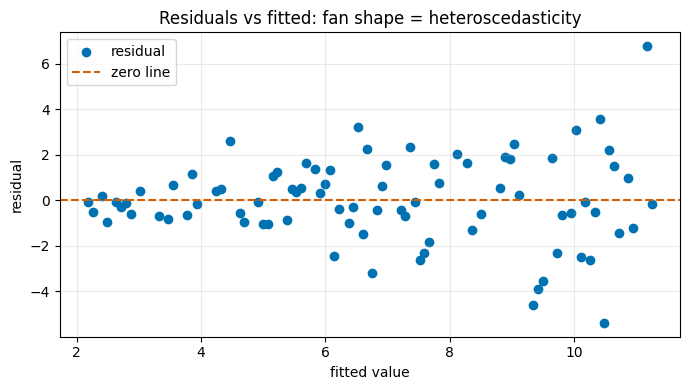

In [3]:
x = np.linspace(0, 10, 120)
y = 2 + x + rng.normal(0, 0.3 + x * 0.35, size=x.size)
X = x[:, None]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=4
)
model = LinearRegression().fit(X_train, y_train)
fitted = model.predict(X_train)
resid = y_train - fitted

plt.figure(figsize=(7, 4))
plt.scatter(fitted, resid, color=OKABE_ITO[0], label='residual')
plt.axhline(0, color=OKABE_ITO[3], ls='--', label='zero line')
plt.title('Residuals vs fitted: fan shape = heteroscedasticity')
plt.xlabel('fitted value'); plt.ylabel('residual')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## 3. Q–Q plot for residual normality
A quantile–quantile plot compares residual quantiles against a normal distribution. Points on the 45-degree line indicate approximate normality; systematic departures indicate skew or heavy tails. Normal residuals support small-sample inference but are not required for OLS coefficients to be unbiased.

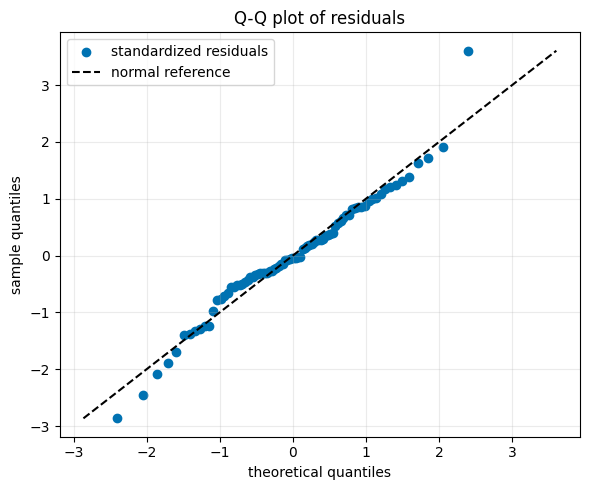

In [4]:
std_resid = (resid - resid.mean()) / resid.std(ddof=1)
osm, osr = stats.probplot(std_resid, dist='norm', fit=False)

plt.figure(figsize=(6, 5))
plt.scatter(osm, osr, color=OKABE_ITO[0], label='standardized residuals')
lim = [min(osm.min(), osr.min()), max(osm.max(), osr.max())]
plt.plot(lim, lim, color='black', ls='--', label='normal reference')
plt.title('Q-Q plot of residuals')
plt.xlabel('theoretical quantiles'); plt.ylabel('sample quantiles')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## 4. Multicollinearity: correlation heatmap + VIF
The variance inflation factor (VIF) quantifies how much a feature's variance is inflated by collinearity. VIF = 1 / (1 - R²) where R² comes from regressing that feature on the others. VIF > 5 (sometimes 10) flags problematic collinearity. Values are annotated directly on the heatmap and printed as a table.

feature            VIF
----------------------
x1              416.86
x2 (~x1)        416.65
x3                1.02


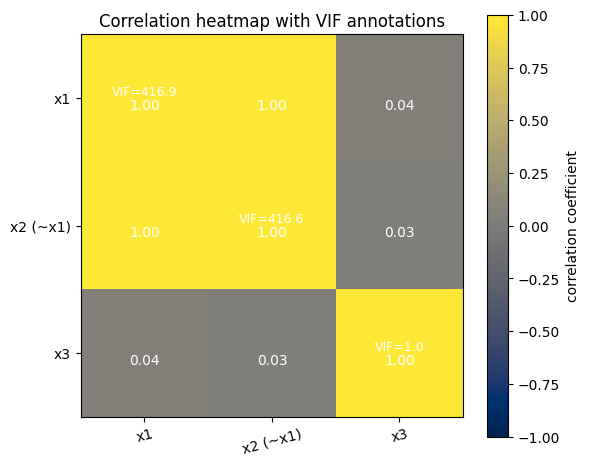

In [5]:
a = rng.normal(size=150)
Xc = np.c_[a, a + rng.normal(0, 0.05, size=150), rng.normal(size=150)]
names = ['x1', 'x2 (~x1)', 'x3']

def vif(matrix, j):
    others = np.delete(matrix, j, axis=1)
    r2 = LinearRegression().fit(others, matrix[:, j]).score(others, matrix[:, j])
    return np.inf if r2 >= 1 - 1e-12 else 1.0 / (1.0 - r2)

vifs = [vif(Xc, j) for j in range(Xc.shape[1])]
print(f'{"feature":<12}{"VIF":>10}')
print('-' * 22)
for name, v in zip(names, vifs):
    print(f'{name:<12}{v:>10.2f}')

corr = np.corrcoef(Xc, rowvar=False)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='cividis')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('correlation coefficient')
ax.set_xticks(range(3)); ax.set_xticklabels(names, rotation=15)
ax.set_yticks(range(3)); ax.set_yticklabels(names)
ax.set_title('Correlation heatmap with VIF annotations')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='top',
                color='white')
for i in range(3):
    ax.text(i, i, f'\nVIF={vifs[i]:.1f}', ha='center', va='bottom',
            color='white', fontsize=9)
plt.tight_layout(); plt.show()


## 5. Actual Ridge comparison on collinear data
Collinearity makes individual OLS coefficients unstable but does not automatically ruin predictions. Here we fit real OLS and a CV-selected Ridge on the same collinear data (split before fitting) and compare held-out performance and coefficient stability.

model                test R2    test MSE
----------------------------------------
OLS                    0.858       0.978
RidgeCV(a=3.7)         0.856       0.991


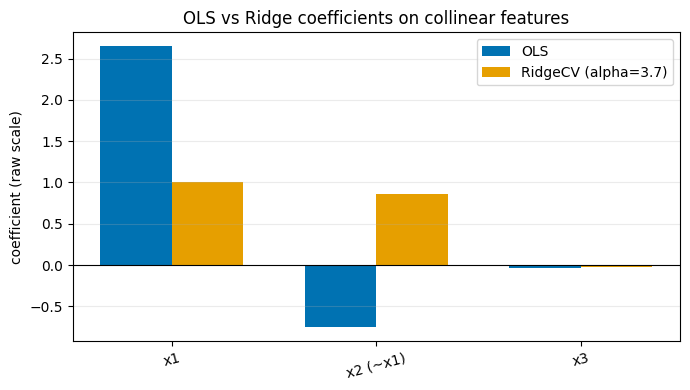

In [6]:
y_c = 2 * a + rng.normal(0, 1, size=150)  # depends on latent a only
Xtr, Xte, ytr, yte = train_test_split(Xc, y_c, test_size=0.3,
                                      random_state=4)

ols = LinearRegression().fit(Xtr, ytr)
alphas = np.logspace(-2, 3, 40)
ridge = Pipeline([
    ('scale', StandardScaler()),
    ('ridge', RidgeCV(alphas=alphas)),
]).fit(Xtr, ytr)
best_alpha = ridge.named_steps['ridge'].alpha_

ols_pred = ols.predict(Xte)
ridge_pred = ridge.predict(Xte)
print(f'{"model":<18}{"test R2":>10}{"test MSE":>12}')
print('-' * 40)
print(f'{"OLS":<18}{r2_score(yte, ols_pred):>10.3f}'
      f'{mean_squared_error(yte, ols_pred):>12.3f}')
print(f'{f"RidgeCV(a={best_alpha:.2g})":<18}{r2_score(yte, ridge_pred):>10.3f}'
      f'{mean_squared_error(yte, ridge_pred):>12.3f}')

# Ridge coef is on scaled features; rescale to raw units for comparison.
scaler = ridge.named_steps['scale']
ridge_coef_raw = ridge.named_steps['ridge'].coef_ / scaler.scale_

width = 0.35
pos = np.arange(len(names))
plt.figure(figsize=(7, 4))
plt.bar(pos - width / 2, ols.coef_, width, color=OKABE_ITO[0], label='OLS')
plt.bar(pos + width / 2, ridge_coef_raw, width, color=OKABE_ITO[1],
        label=f'RidgeCV (alpha={best_alpha:.2g})')
plt.axhline(0, color='black', lw=0.8)
plt.xticks(pos, names, rotation=15)
plt.title('OLS vs Ridge coefficients on collinear features')
plt.ylabel('coefficient (raw scale)'); plt.legend()
plt.grid(alpha=0.25, axis='y'); plt.tight_layout(); plt.show()


## Takeaways
- Residual plots and Q–Q plots check variance and normality assumptions.
- VIF quantifies multicollinearity; high VIF means unstable OLS coefficients.
- Ridge (tuned by CV) can stabilize coefficients while keeping competitive held-out predictions.